<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/YouTube%20Trending%20Videos%20Stats%202026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YouTube Trending Videos Stats 2026

### YouTube Trending Videos Dataset: Key Insights

This analysis explores a dataset of YouTube trending videos from India, aiming to uncover factors contributing to a video's virality and algorithmic promotion. The dataset, `IN_Trending.csv`, contains 13 columns including `video_id`, `trending_date`, `title`, `channel_title`, `views`, `likes`, `dislikes`, `publish_time`, `category_id`, `tags`, `comments`, `channel_id`, and `description`.

### Data Overview & Preprocessing
The dataset comprises 16,199 entries initially. After removing duplicate descriptions, we were left with 12,313 unique entries. A notable observation during the initial exploration was the `dislikes` column, which consistently showed '0' values across the dataset. This is likely due to YouTube's API update that hides public dislike counts, rendering this feature less useful for our analysis of 'controversy multipliers'. The `trending_date` column showed only one unique value (`26.26.02`), indicating that all entries were recorded on the same trending date, limiting its utility for time-series analysis.

### Feature Engineering & Statistical Insights
To better understand audience engagement and algorithmic behavior, several new features were engineered:
- **`Engagement_Rate_%`**: Calculated as `((likes + comments) / views) * 100`.
- **`Like_Rate_%`**: Calculated as `(likes / views) * 100`.
- **`Title_Length`**: The character length of the video's title.
- **`Tags_Count`**: The number of tags associated with a video.
- **`Log_Views`**: A logarithmic transformation of `views` to normalize its skewed distribution for correlation analysis.

**Key statistical findings include:**
- **Algorithm Trigger (Engagement Rate)**: An Independent T-Test was performed to check if higher engagement rates significantly correlate with higher view tiers (top 25% vs. standard). The P-value of `0.278` suggests that in this specific dataset, the engagement rate does **not** mathematically trigger algorithmic promotion. This contradicts the common assumption that higher engagement automatically leads to more views in a statistically significant manner, at least for this particular dataset's definition of 'viral'.
- **Controversy Multiplier**: Due to the absence of meaningful dislike data (all values were 0), we could not effectively test the hypothesis that controversy (high dislikes) leads to increased viewership. YouTube's API changes have made this analysis challenging.
- **Click-Hook Diagnostic (Title Length)**: A Pearson correlation between `Title_Length` and `Log_Views` revealed a correlation coefficient of `-0.374` with a P-value of `0.0`. This indicates a statistically significant **negative correlation**. The insight derived is that **shorter, punchier titles mathematically generate more views**, suggesting that brevity and impact in titles are more effective for algorithmic reach.

### Machine Learning for Virality Prediction
To identify key drivers of extreme virality, a Random Forest Classifier was trained to predict whether a video would become "Mega-Viral" (defined as being in the top 10% of views). The model was trained on engineered features like `Engagement_Rate_%`, `Like_Rate_%`, `Title_Length`, `Tags_Count`, and `comments`.

**Model Performance & Feature Importance:**
- **ROC-AUC Score**: The model achieved an impressive ROC-AUC score of `0.9675`, indicating excellent discriminatory power between standard and mega-viral videos.
- **Classification Report**: The model showed strong performance in classifying both standard and mega-viral videos. While it had high precision and recall for standard videos (0.99 precision, 0.93 recall), its performance for mega-viral videos was also respectable (0.59 precision, 0.89 recall). This suggests that the model is quite effective at identifying videos that are likely to achieve extreme popularity.
- **Algorithmic Feature Importance**: The analysis of feature importance revealed that **`comments`** were the most significant driver of mega-viral status, with a weight of `0.637`. This is a crucial insight: while engagement rate might not directly trigger the algorithm in a broad sense, the sheer volume of comments is a powerful indicator and likely a strong contributing factor to a video's extreme virality. `Title_Length` and `Engagement_Rate_%` also played notable roles, albeit less significant than `comments`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d bsthere/youtube-trending-videos-stats-2026

# Unziping the downloaded file
!unzip youtube-trending-videos-stats-2026.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/bsthere/youtube-trending-videos-stats-2026
License(s): CC0-1.0
youtube-trending-videos-stats-2026.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  youtube-trending-videos-stats-2026.zip
  inflating: BR_Trending.csv         
  inflating: CA_Trending.csv         
  inflating: DE_Trending.csv         
  inflating: FR_Trending.csv         
  inflating: GB_Trending.csv         
  inflating: IN_Trending.csv         
  inflating: JP_Trending.csv         
  inflating: KR_Trending.csv         
  inflating: MX_Trending.csv         
  inflating: RU_Trending.csv         
  inflating: US_Trending.csv         
  inflating: data_dictionary.csv     


# Data Inspection

In [6]:
df = pd.read_csv('IN_Trending.csv')
df.head(11)

,video_id,trending_date,title,channel_title,views,likes,dislikes,publish_time,category_id,tags,comments,channel_id,description
0,iAtoZar5W58,26.26.02,Aaya Sher - Lyrical | The Paradise | Nani | An...,Saregama Telugu,21242383,836273,0,2026-02-24T14:44:06Z,10,Anirudh Ravichander|The Paradise Theme OST|The...,24917,UC68nKdrLbLL0Vj7ilVkLmmg,"For more latest songs & videos, subscribe 👉 ht..."
1,BCQwSlYlEe8,26.26.02,Thaai Kizhavi - Official Trailer | Radikaa Sar...,Saregama Tamil,1913244,43317,0,2026-02-23T11:30:09Z,1,Maatikitaan Minorkunju|Maatikitaan Minorkunju ...,1181,UCzee67JnEcuvjErRyWP3GpQ,"For more latest songs & videos, subscribe 👉 ht..."
2,tVDiaaVkfNw,26.26.02,"Minecraft, But Every Mob in Chest!",Carry Depie,463090,9151,0,2026-02-26T09:01:45Z,20,carry depie|minecraft,434,UClqifC6Nd7v-IfTqce4k62A,in this video every mob become chest in minecr...
3,DBC2461TQbQ,26.26.02,"#Video - चोली के समान - #Ashish Yadav, Khushi ...",Aashish Yadav Entertainment,699235,60368,0,2026-02-26T00:30:09Z,10,Ashish Yadav|चोली के समान|Khushi Kakkar|ashish...,6468,UCjaOWpDTaZKe63ApNJ8BLPg,►Album :- चोली के समान ►Song :- Choli Ke Saman...
4,qj0TyXhGaLw,26.26.02,3000 Crore Plan Dhurandhar 2 Secret Deal | Dee...,Filmi Indian,232987,11738,0,2026-02-25T09:16:32Z,24,dhurandhar 2|dhurandhar 2 trailer|dhurandhar|d...,1065,UCeiAKuJGZrIjYvaq0nMwbJg,3000 Crore Plan Dhurandhar 2 Secret Deal Expla...
5,YOY_g9CyEco,26.26.02,I Trained Like a Parasite For 24 Hours in Mine...,ProBoiz 95,266344,13869,0,2026-02-26T11:41:22Z,20,minecraft|parasite in minecraft|minecraft para...,1933,UCSncGB_s0tuWN-4l-58mmvQ,"So Today, I Trained Like a Parasite for 24 Hou..."
6,x0aMsjhFxeE,26.26.02,Ram Ji Aake Bhala Karenge | Bhooth Bangla | Ak...,Zee Music Company,2464608,73472,0,2026-02-26T06:34:02Z,10,ram ji aake bhala karenge|ramji aake bhala kar...,10758,UCFFbwnve3yF62-tVXkTyHqg,👉🏻 SUBSCRIBE to Zee Music Company - https://bi...
7,AN8hv-JQZIw,26.26.02,Band Melam Official Teaser | Harsh Roshan | Sr...,Aditya Music,392089,10369,0,2026-02-24T13:00:01Z,10,Band Melam Teaser|Band Melam Teaser Telugu|Ban...,152,UCNApqoVYJbYSrni4YsbXzyQ,Here’s the Official Teaser of Band Melam Movie...
8,GJtYMCI43OQ,26.26.02,GRANNY TRAPPED MOTU PATLU IN INDIAN BIKE DRIVI...,Vamp Plays,674731,7449,0,2026-02-25T09:00:00Z,24,Indian bike driving 3d|Motu patlu|Motu patlu i...,216,UCBeAbD9rRJ_YhMli7bEH9tQ,GRANNY TRAPPED MOTU PATLU IN INDIAN BIKE DRIVI...
9,T0EA6U6gs2Q,26.26.02,Sudasha Brata Bahi Gita | ସୁଦଶା ବ୍ରତ ବହିଗୀତ | ...,Sidharth Bhakti,215026,2064,0,2026-02-25T23:00:41Z,10,sidharth bhakti|sidharth bhakti song|siddharth...,178,UCTCtBVxD_OSSLuaOk5YpiWA,ଜୟ ମା’ ମହାଲକ୍ଷ୍ମୀ... 🙏 ଓଡ଼ିଆ ଘରର ପରମ୍ପରାରେ ସୁଦ...


In [8]:
df.tail(11)

,video_id,trending_date,title,channel_title,views,likes,dislikes,publish_time,category_id,tags,comments,channel_id,description
16188,_mpT9mt89LY,26.26.02,SEVA SAMDHIN KE HOYI I सेवा समधिन के होई I VI...,B4U Bhojpuri,13921,68,0,2026-02-18T12:30:47Z,1,seva samdhin ke hoyi|bitiya damad bhojpuri mov...,1,UCIobY5Y-ly9Bo458yjy36OQ,#meghashree #rakeshbabu #kanchanmishra #premdu...
16189,vMTbHvupj-Q,26.26.02,KAISAN LIKHLA TAKDEER HO I कईसन लिखला तक़दीर हो...,B4U Bhojpuri,181346,311,0,2026-02-18T03:30:45Z,1,collector sahiba|collector sahiba movie|bhojpu...,7,UCIobY5Y-ly9Bo458yjy36OQ,#sanjanapandey #gauravjha #omjha #pyarelalyad...
16190,dcIw-WE5egQ,26.26.02,WORLD TELEVISION PREMIER I DAKSHIN BHARTIYA BA...,B4U Bhojpuri,123886,598,0,2026-02-17T12:31:01Z,1,[none],10,UCIobY5Y-ly9Bo458yjy36OQ,#anjanasingh #rakeshbabu #dakshinbhartiyabahu ...
16191,eivFZlJYrOw,26.26.02,KAISAN LIKHLA TAKDEER HO I कईसन लिखला तक़दीर हो...,B4U Bhojpuri,75365,189,0,2026-02-17T03:30:26Z,1,kaisan likhla|bhojpuri gana|bhojpuri gaane|bho...,5,UCIobY5Y-ly9Bo458yjy36OQ,#sanjanapandey #gauravjha #omjha #pyarelalyad...
16192,gJt9J3qehrE,26.26.02,Maare Maai Baap Ke Karejawa Mein Chhuriya I मा...,B4U Bhojpuri,22952,54,0,2026-02-16T03:30:24Z,1,[none],2,UCIobY5Y-ly9Bo458yjy36OQ,#manibhattachariya #meghashree #ayazkhan #prem...
16193,H-jgsgaSwII,26.26.02,COLLECTOR SAHIBA I कलेक्टर साहिबा I SANJANA PA...,B4U Bhojpuri,22647049,143765,0,2026-02-14T02:30:25Z,1,bhojpuri movie|bhojpuri movie collector sahiba...,2667,UCIobY5Y-ly9Bo458yjy36OQ,#sanjanapandey #gauravjha #vinodmishra #amitsh...
16194,8vnzBO2U9R8,26.26.02,Maare Maai Baap Ke Karejawa Mein Chhuriya I मा...,B4U Bhojpuri,37444,87,0,2026-02-13T03:30:12Z,1,jaisi karni waisi bharni|bhojpuri video|bhojpu...,2,UCIobY5Y-ly9Bo458yjy36OQ,#manibhattachariya #meghashree #ayazkhan #prem...
16195,rRmkxXY9kXQ,26.26.02,HUM HAIEN JETHANI I हम हई जेठानी-Part-05 | RAN...,B4U Bhojpuri,29826,90,0,2026-02-12T12:31:12Z,1,hum hai jethani|hum haien jethani|rani chatter...,2,UCIobY5Y-ly9Bo458yjy36OQ,#ranichatterjee #khushijha #sonalimishra #ayaz...
16196,elzjjoy8kf8,26.26.02,"“कलेक्टर साहिबा “ 14 फ़रवरी ,शनिवार सुबह 8 बजे...",B4U Bhojpuri,54947,623,0,2026-02-12T07:07:40Z,1,[none],7,UCIobY5Y-ly9Bo458yjy36OQ,@sanjanapandey00 @ursgauravjha @santoshsrivast...
16197,kj0yf2lP3-Y,26.26.02,SAAHEB SE CHAPRASI HO GAYINI I साहेब से चपर...,B4U Bhojpuri,242429,570,0,2026-02-12T03:30:39Z,1,collector sahab gaane|collector sahab songs|co...,10,UCIobY5Y-ly9Bo458yjy36OQ,#sanjanapandey #gauravjha #omjha #pyarelalyad...


In [9]:
df.shape

(16199, 13)

In [10]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'views', 'likes',
       'dislikes', 'publish_time', 'category_id', 'tags', 'comments',
       'channel_id', 'description'],
      dtype='object')

In [11]:
df.dtypes

,0
video_id,object
trending_date,object
title,object
channel_title,object
views,int64
likes,int64
dislikes,int64
publish_time,object
category_id,int64
tags,object


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16199 entries, 0 to 16198
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       16199 non-null  object
 1   trending_date  16199 non-null  object
 2   title          16199 non-null  object
 3   channel_title  16199 non-null  object
 4   views          16199 non-null  int64 
 5   likes          16199 non-null  int64 
 6   dislikes       16199 non-null  int64 
 7   publish_time   16199 non-null  object
 8   category_id    16199 non-null  int64 
 9   tags           16199 non-null  object
 10  comments       16199 non-null  int64 
 11  channel_id     16199 non-null  object
 12  description    14852 non-null  object
dtypes: int64(5), object(8)
memory usage: 1.6+ MB


In [13]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,16199,16199,G7XSYRCVA10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,16199,1,26.26.02,16199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,16199,14975,Payal Ki Khanak | Official Video | Hindi New S...,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,16199,980,T-Series Tamil,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,16199.0,NaN,NaN,NaN,1370102.126119,4439475.41591,0.0,18934.0,180600.0,976383.5,274334759.0
likes,16199.0,NaN,NaN,NaN,40210.943021,120629.265543,0.0,250.0,3513.0,26604.0,3524649.0
dislikes,16199.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
publish_time,16199,15912,2024-12-27T13:17:16Z,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,16199.0,NaN,NaN,NaN,16.446756,6.338829,1.0,10.0,20.0,22.0,28.0
tags,16199,8889,[none],2767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
views,0
likes,0
dislikes,0
publish_time,0
category_id,0
tags,0


In [18]:
df.drop_duplicates(subset=['description'], inplace = True)
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
views,0
likes,0
dislikes,0
publish_time,0
category_id,0
tags,0


In [16]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

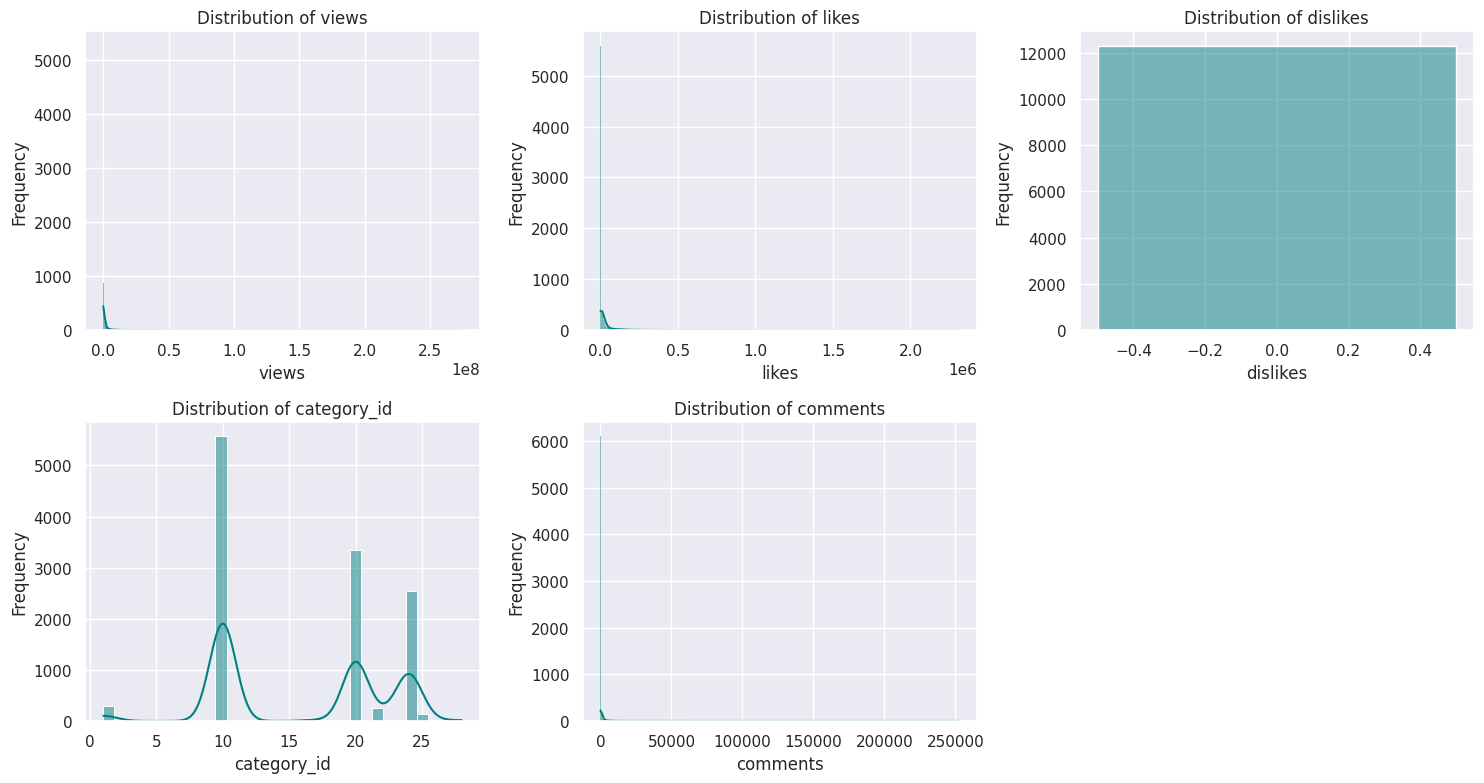

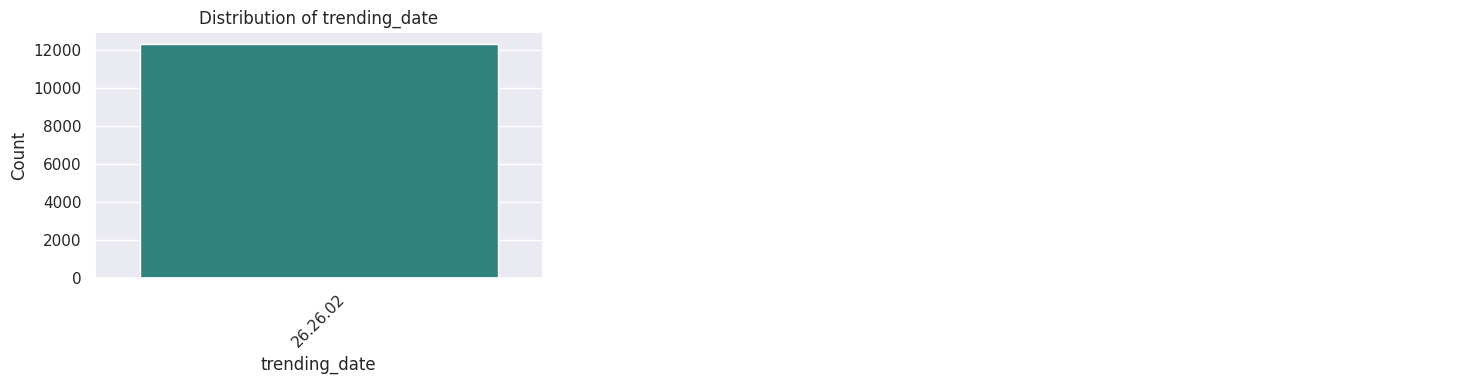

--- Categorical Value Counts ---

Value counts for trending_date:
trending_date
26.26.02    12313
Name: count, dtype: int64


In [19]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

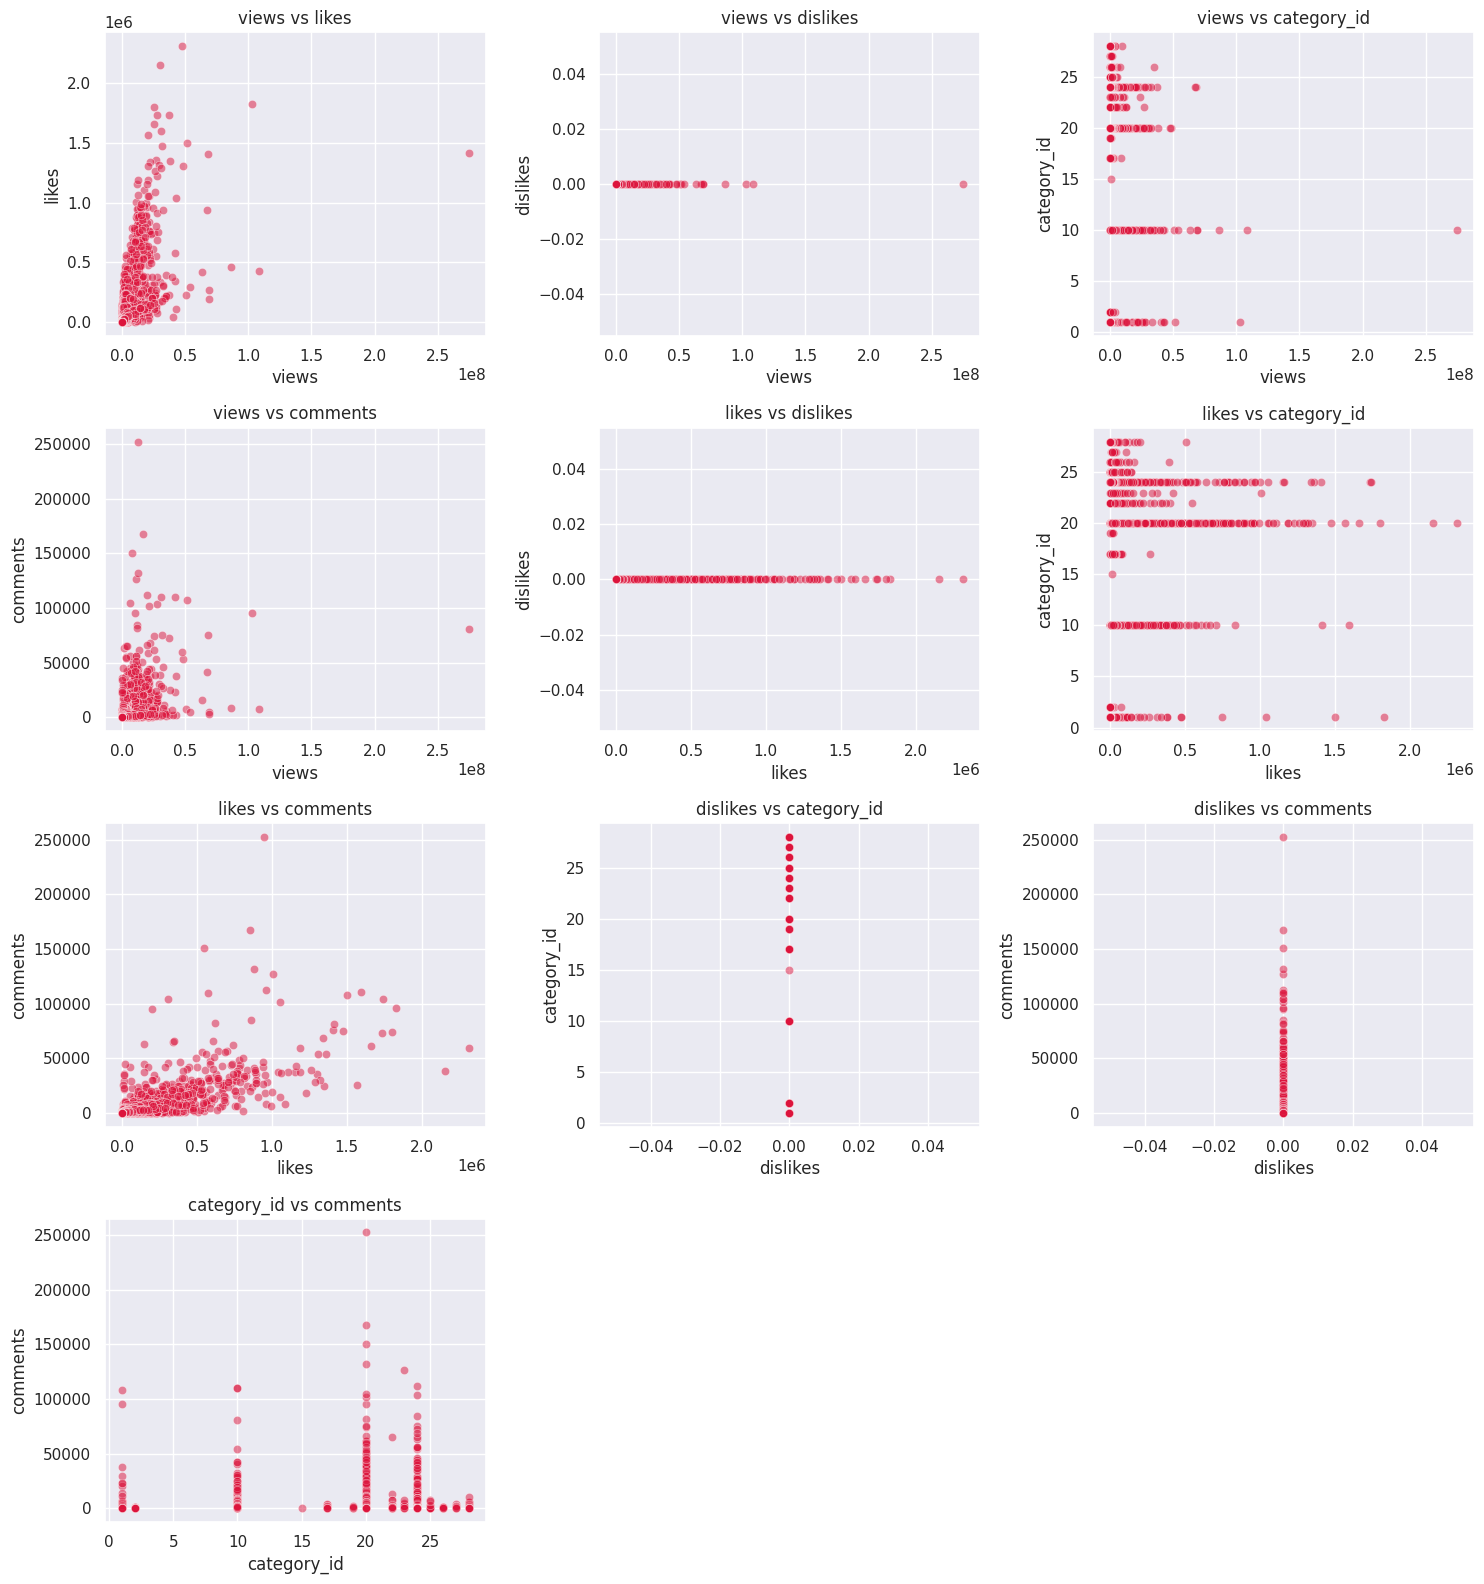

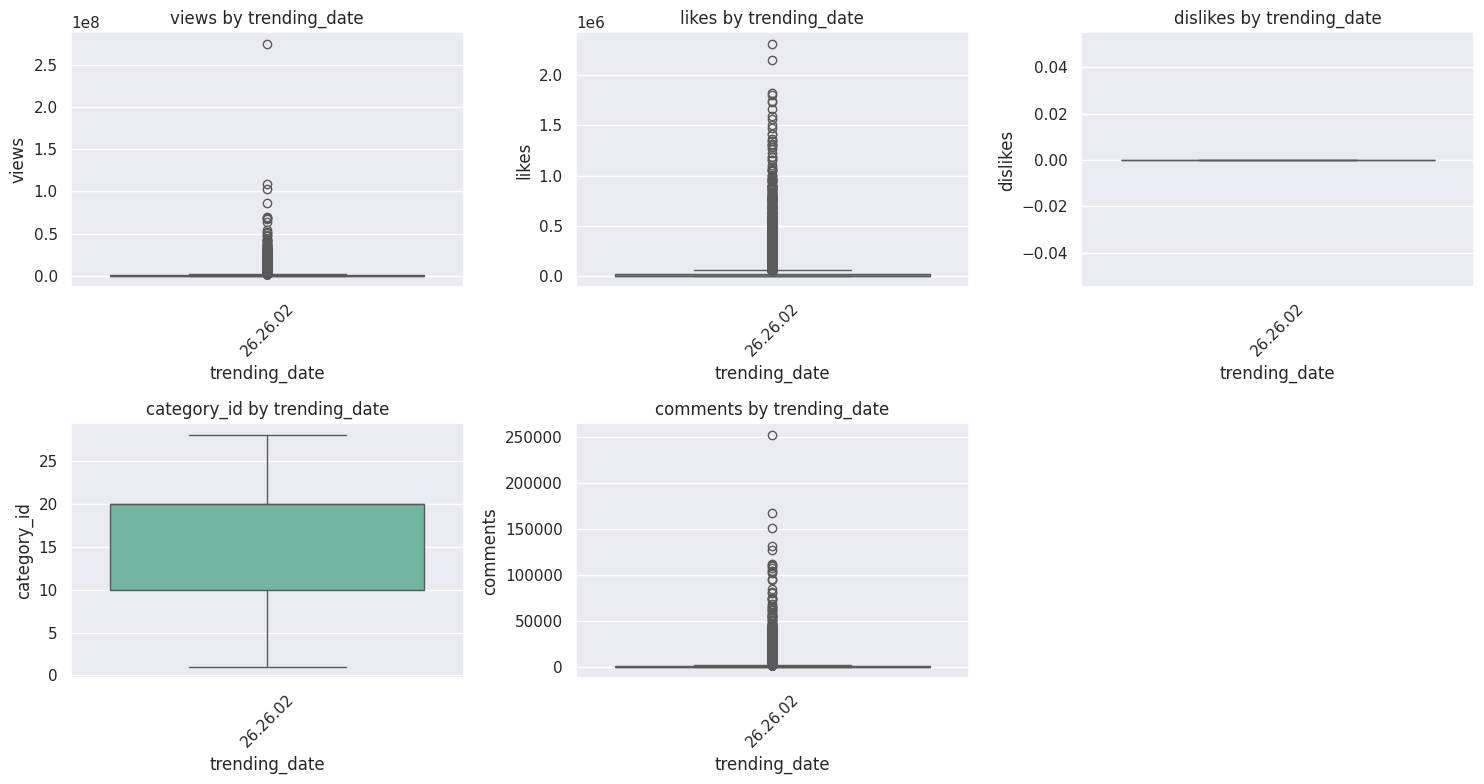

In [20]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: trending_date...


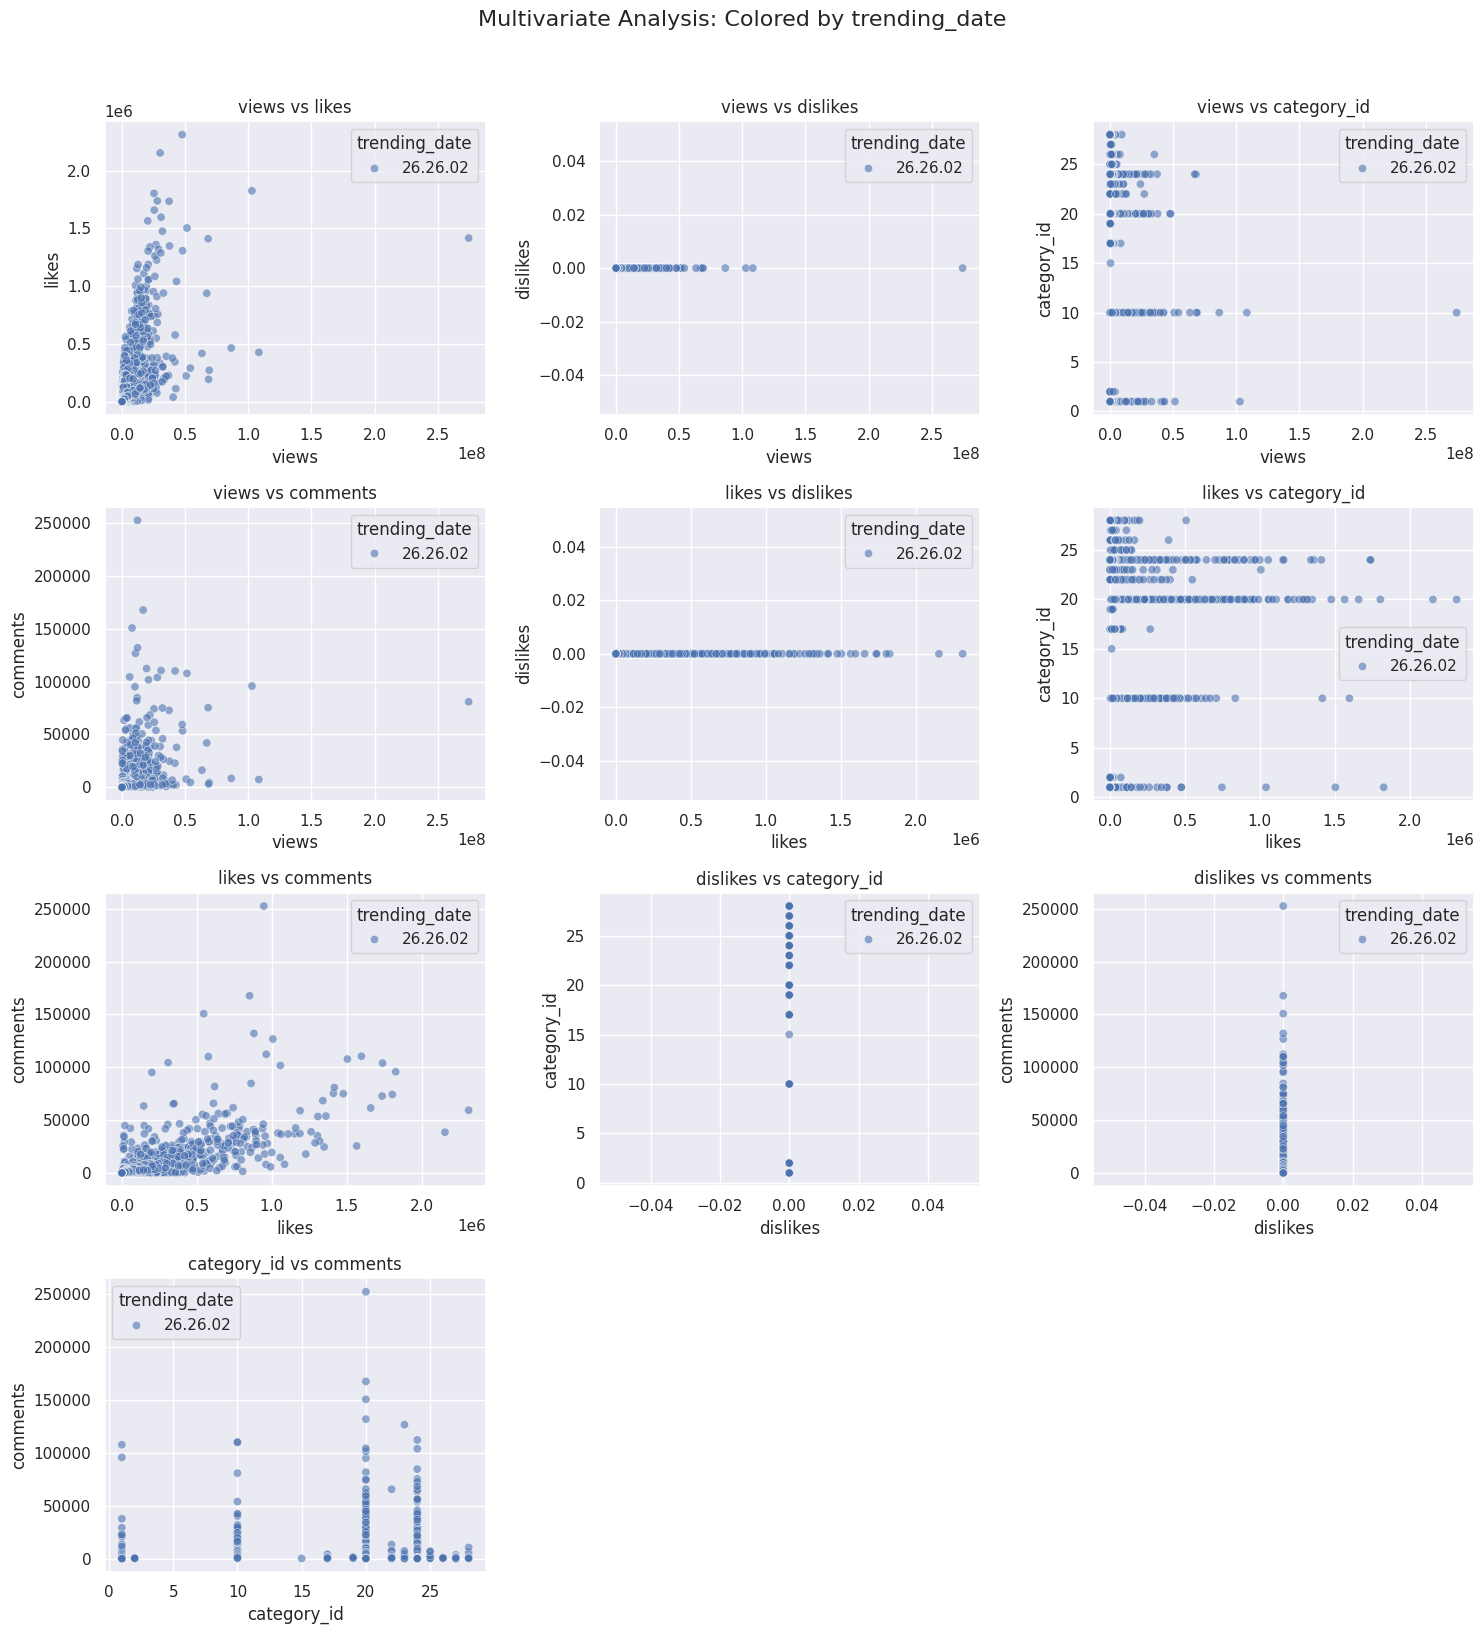

In [21]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

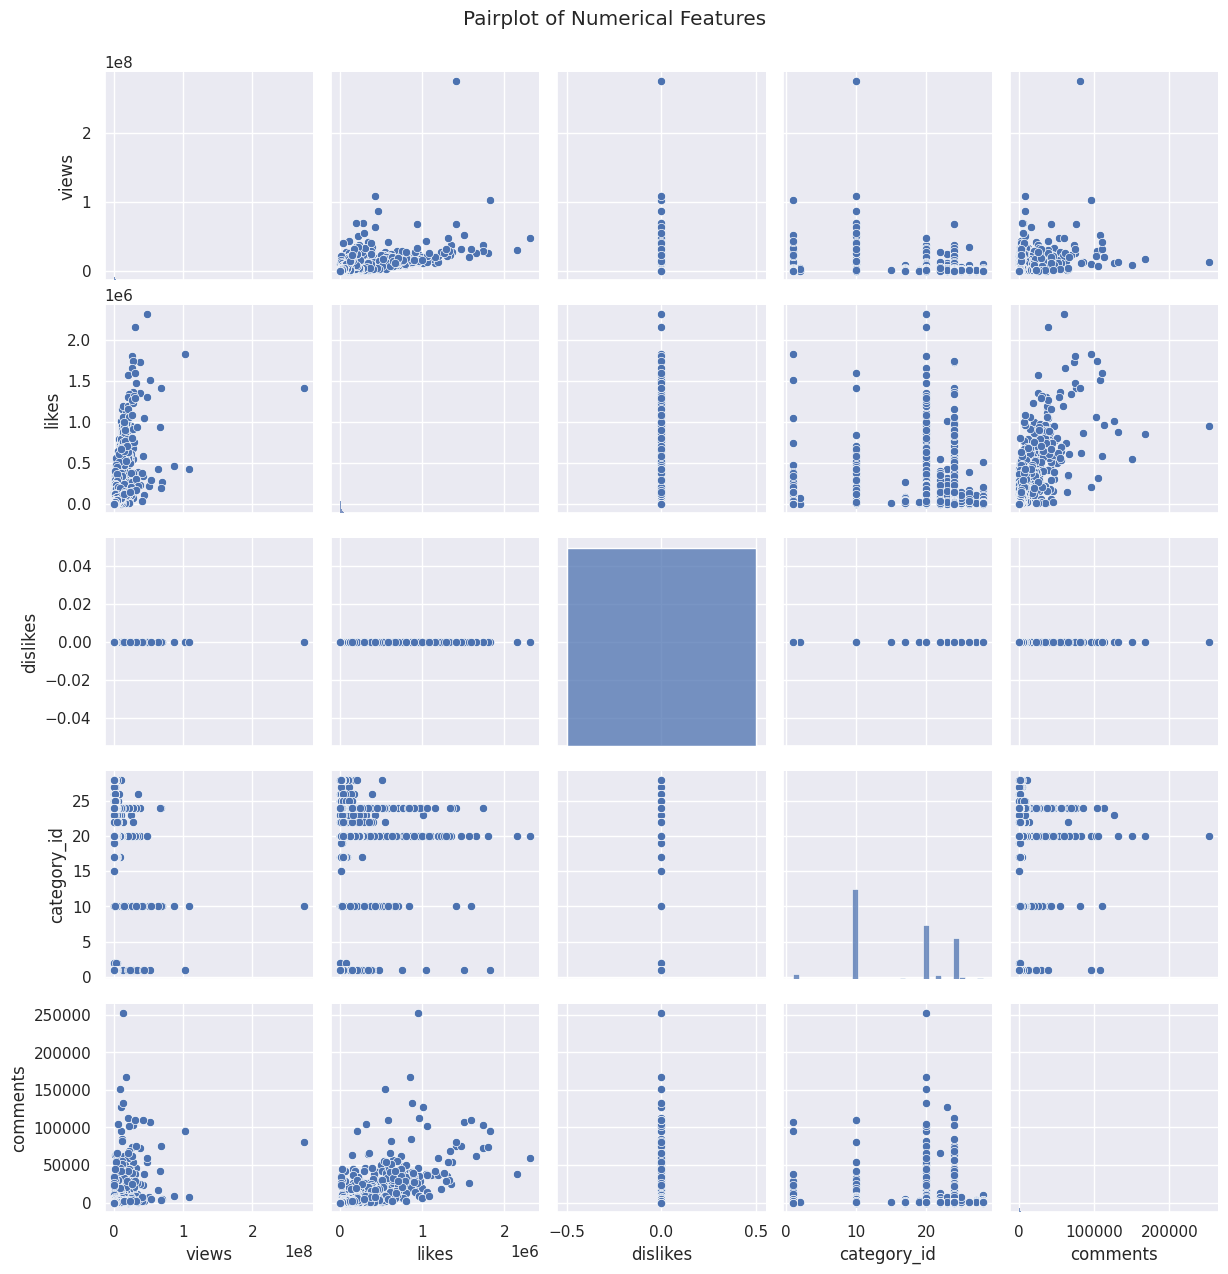

In [22]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

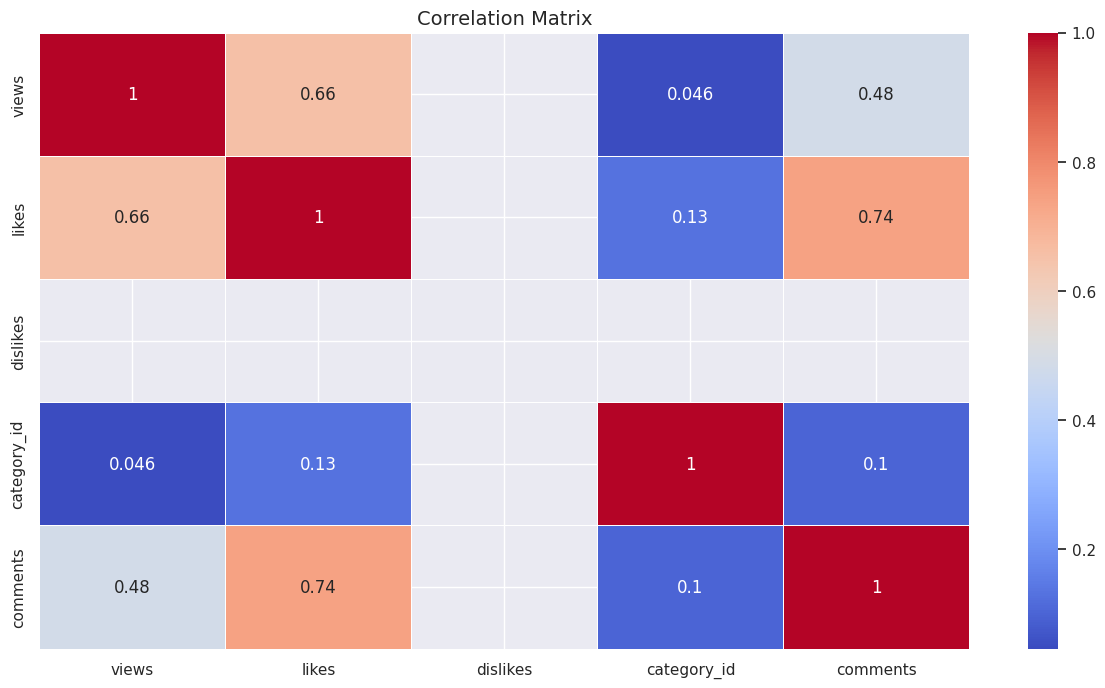

In [23]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Feature Engineering

--- 1. ENGINEERING ALGORITHMIC FEATURES ---
 Engineered: Engagement_Rate_%, Like_Rate_%, and Title_Length.

--- 2. THE ALGORITHM TRIGGER (INDEPENDENT T-TEST) ---
T-Test P-Value: 2.7819e-01
 Insight: Engagement rate does not mathematically trigger algorithmic promotion in this dataset.


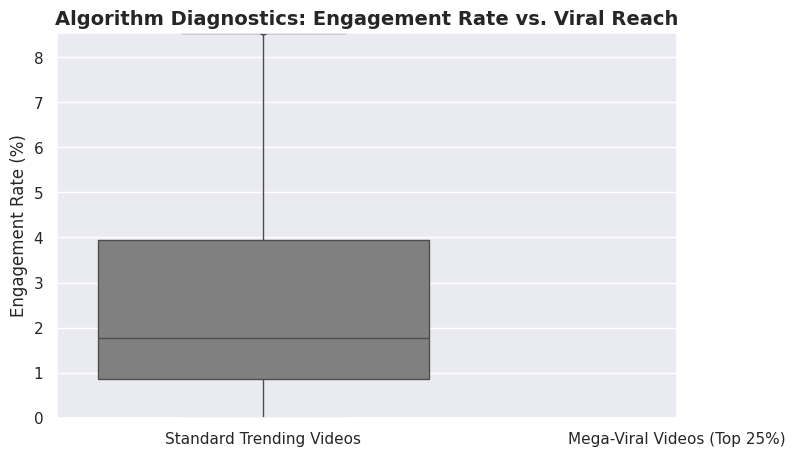


--- 3. THE CONTROVERSY MULTIPLIER (SPEARMAN CORRELATION) ---
 Dislike data is missing or zeroed out (Likely due to YouTube's API update hiding dislikes).

--- 4. THE CLICK-HOOK DIAGNOSTIC (PEARSON CORRELATION) ---
Pearson Correlation (Title Length vs. Log Views): -0.3740
P-Value: 0.0000e+00
 Insight: Negative correlation detected. Short, punchy titles mathematically generate more views.


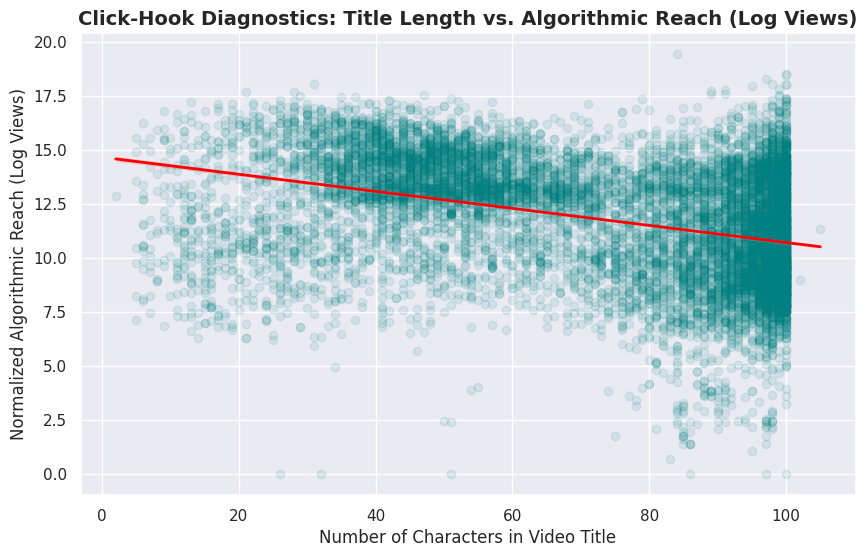

In [27]:
import scipy.stats as stats


print("--- 1. ENGINEERING ALGORITHMIC FEATURES ---")
# Raw numbers are useless in digital media. 10,000 likes is terrible if a video has 10 million views.
# We must calculate the 'Engagement Rates' to measure true audience retention.

# Adding a tiny constant (0.01) to prevent Division by Zero errors
df['Engagement_Rate_%'] = ((df['likes'] + df['comments']) / (df['views'] + 0.01)) * 100
df['Like_Rate_%'] = (df['likes'] / (df['views'] + 0.01)) * 100

# Extracting Title Length to test Click-Hook strategies
df['Title_Length'] = df['title'].astype(str).apply(len)

print(" Engineered: Engagement_Rate_%, Like_Rate_%, and Title_Length.")


print("\n--- 2. THE ALGORITHM TRIGGER (INDEPENDENT T-TEST) ---")
# The YouTube algorithm actively promotes videos with higher engagement rates, pushing them to higher view tiers.

# We splitting the dataset into Top-Tier Views (Top 25%) and Standard Views (Bottom 75%)
view_threshold = df['views'].quantile(0.75)
viral_videos = df[df['views'] >= view_threshold]['Engagement_Rate_%'].dropna()
standard_videos = df[df['views'] < view_threshold]['Engagement_Rate_%'].dropna()

# Running an Independent T-Test with unequal variance (Welch's T-Test)
t_stat, p_val_engagement = stats.ttest_ind(viral_videos, standard_videos, equal_var=False)

print(f"T-Test P-Value: {p_val_engagement:.4e}")
if p_val_engagement < 0.05:
    print(" Insight: Statistically significant divergence in engagement rates!")
    print("   -> The YouTube Algorithm is mathematically biased: Videos that successfully farm engagement are exponentially rewarded with views.")
else:
    print(" Insight: Engagement rate does not mathematically trigger algorithmic promotion in this dataset.")

# Visualizing the Algorithmic Bias
plt.figure(figsize=(8, 5))
sns.boxplot(data=[standard_videos, viral_videos], palette=['gray', 'red'])
plt.xticks([0, 1], ['Standard Trending Videos', 'Mega-Viral Videos (Top 25%)'])
plt.title('Algorithm Diagnostics: Engagement Rate vs. Viral Reach', fontsize=14, fontweight='bold')
plt.ylabel('Engagement Rate (%)', fontsize=12)
plt.ylim(0, df['Engagement_Rate_%'].quantile(0.95)) # Cap outliers for clean visualization
plt.show()


print("\n--- 3. THE CONTROVERSY MULTIPLIER (SPEARMAN CORRELATION) ---")
# Controversy drives traffic. Do videos with massive amounts of dislikes
# mathematically accumulate more views due to hate-watching?
# as we are using Spearman because YouTube views follow an exponential power-law curve, not a linear one.

if 'dislikes' in df.columns and df['dislikes'].sum() > 0:
    corr_data = df[['views', 'dislikes']].dropna()
    spearman_coef, p_val_spearman = stats.spearmanr(corr_data['views'], corr_data['dislikes'])

    print(f"Spearman Correlation Coefficient (Views vs. Dislikes): {spearman_coef:.4f}")
    print(f"P-Value: {p_val_spearman:.4e}")

    if p_val_spearman < 0.05 and spearman_coef > 0.4:
        print(" Insight: Strong positive correlation detected.")
        print("   -> THE CONTROVERSY MULTIPLIER IS REAL: The algorithm does not penalize hate; it mathematically rewards highly disliked videos with massive viewership.")
else:
    print(" Dislike data is missing or zeroed out (Likely due to YouTube's API update hiding dislikes).")


print("\n--- 4. THE CLICK-HOOK DIAGNOSTIC (PEARSON CORRELATION) ---")
# Content Creators always ask: "Should my title be short, or long and descriptive ?"

# Because views are exponentially skewed, we must apply a Logarithmic Transformation, to normalize the variance before running parametric tests like Pearson.
df['Log_Views'] = np.log1p(df['views'])

corr_data_title = df[['Title_Length', 'Log_Views']].dropna()
corr_coef_title, p_val_title = stats.pearsonr(corr_data_title['Title_Length'], corr_data_title['Log_Views'])

print(f"Pearson Correlation (Title Length vs. Log Views): {corr_coef_title:.4f}")
print(f"P-Value: {p_val_title:.4e}")

if p_val_title < 0.05:
    if corr_coef_title < 0:
        print(" Insight: Negative correlation detected. Short, punchy titles mathematically generate more views.")
    else:
        print(" Insight: Positive correlation detected. Long, highly-descriptive titles capture the algorithm better.")
else:
    print(" Insight: Null Hypothesis accepted. The length of a video title has zero statistical impact on its algorithmic reach.")

# Visualizing the Title Strategy
plt.figure(figsize=(10, 6))
sns.regplot(x='Title_Length', y='Log_Views', data=corr_data_title, scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Click-Hook Diagnostics: Title Length vs. Algorithmic Reach (Log Views)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Characters in Video Title', fontsize=12)
plt.ylabel('Normalized Algorithmic Reach (Log Views)', fontsize=12)
plt.show()

# Machine Learning

--- 1. ADVANCED FEATURE EXTRACTION ---
 Engineered: Tags_Count and binary Target Variable (Is_Mega_Viral).

--- 2. DATA SPLITTING & STANDARDIZATION ---
 Feature space mathematically standardized and split.

--- 3. TRAINING THE CLASSIFICATION MODEL ---
 Random Forest Classifier successfully trained.

--- 4. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---
 ROC-AUC Score: 0.9675
   -> (A score of 0.5 is random guessing; 1.0 is mathematical perfection).

Classification Report:
                    precision    recall  f1-score   support

Standard Trend (0)       0.99      0.93      0.96      2217
    Mega-Viral (1)       0.59      0.89      0.71       246

          accuracy                           0.93      2463
         macro avg       0.79      0.91      0.84      2463
      weighted avg       0.95      0.93      0.93      2463



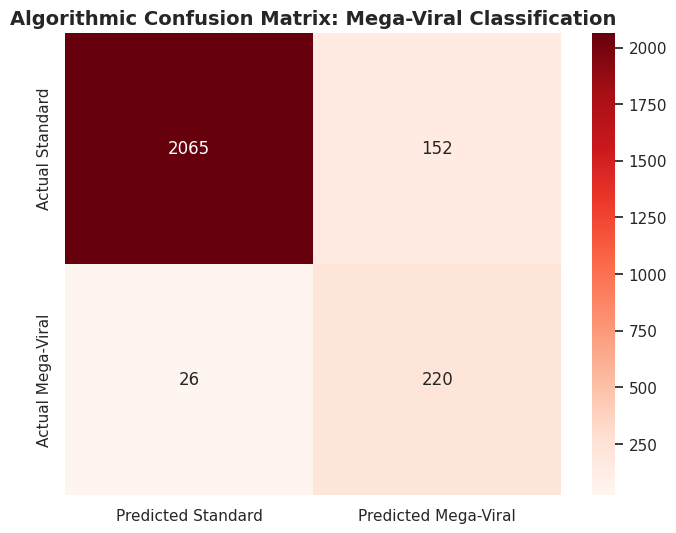


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


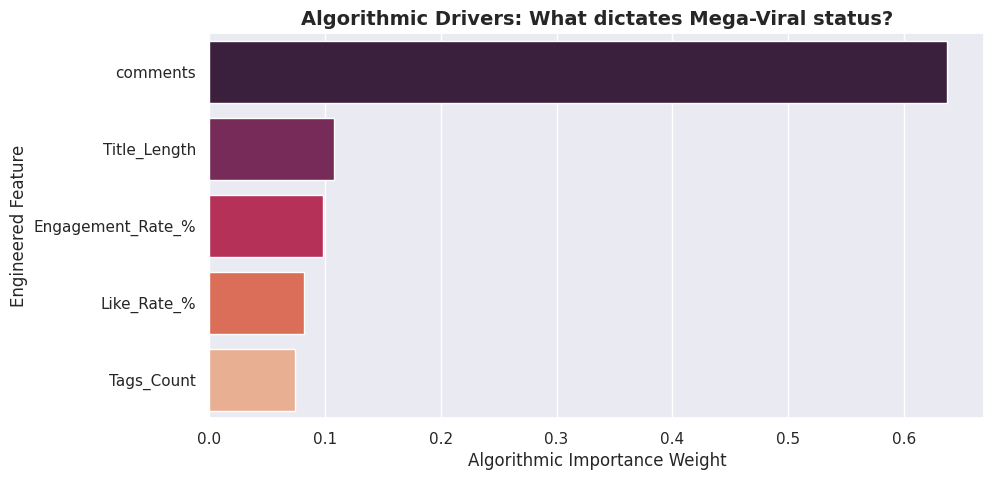

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


print("--- 1. ADVANCED FEATURE EXTRACTION ---")

# Counting the number of tags used (Does "tag-stuffing" actually work?)
df['Tags_Count'] = df['tags'].apply(lambda x: len(str(x).split('|')) if pd.notnull(x) else 0)

# Target Definition: We classify a video as "Mega-Viral" (1) if it is in the Top 10% of views.
# Otherwise, it is just a Standard Trending video (0).
viral_threshold = df['views'].quantile(0.90)
df['Is_Mega_Viral'] = np.where(df['views'] >= viral_threshold, 1, 0)

# Defineing the algorithmic feature matrix
ml_features = ['Engagement_Rate_%', 'Like_Rate_%', 'Title_Length', 'Tags_Count', 'comments']

# Sanitizing the dataset (drop NaNs in our specific features)
ml_df = df.dropna(subset=ml_features + ['Is_Mega_Viral']).copy()

X = ml_df[ml_features]
y = ml_df['Is_Mega_Viral']

print(" Engineered: Tags_Count and binary Target Variable (Is_Mega_Viral).")


print("\n--- 2. DATA SPLITTING & STANDARDIZATION ---")
# Splitting the data into Training (80%) and Out-of-Sample Testing (20%)
# We use 'stratify=y' to ensure the algorithm sees an equal ratio of Mega-Viral videos in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the StandardScaler to normalize variance across vastly different metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature space mathematically standardized and split.")


print("\n--- 3. TRAINING THE CLASSIFICATION MODEL ---")
# Deploying a Random Forest Classifier. We use 'class_weight=balanced' because
# Mega-Viral videos are rare (only 10% of the dataset), which creates a heavily imbalanced target.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

print(" Random Forest Classifier successfully trained.")


print("\n--- 4. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---")
# Forceing the model to predict the unseen Testing Set
ml_predictions = rf_model.predict(X_test_scaled)
ml_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculating the ROC-AUC Score (A measure of the model's ability to distinguish between classes)
roc_auc = roc_auc_score(y_test, ml_probabilities)
print(f" ROC-AUC Score: {roc_auc:.4f}")
print("   -> (A score of 0.5 is random guessing; 1.0 is mathematical perfection).")

print("\nClassification Report:")
print(classification_report(y_test, ml_predictions, target_names=['Standard Trend (0)', 'Mega-Viral (1)']))

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, ml_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Standard', 'Predicted Mega-Viral'],
            yticklabels=['Actual Standard', 'Actual Mega-Viral'])
plt.title('Algorithmic Confusion Matrix: Mega-Viral Classification', fontsize=14, fontweight='bold')
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
# Extracting the mathematical weights to see which metadata dictates extreme virality.
importances = pd.Series(rf_model.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Algorithmic Drivers: What dictates Mega-Viral status?', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You